In [32]:
# ==============================================================================
# The Climate Cost of Urban Sprawl within Exeter-Cranbrook Corridor
# Focus: Quantifying the Effects of Urban Sprawl in term of Urban Heat Island Intensity
# Date: April 2026
# ==============================================================================

In [33]:
%pip install rasterio geemap

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# Import required libraries
import os
import ee
import geemap
import json

In [36]:
import geemap
print(geemap.__version__)
print(hasattr(geemap, "geojson_to_ee"))

0.38.4
False


In [37]:
# Setup Paths
# Local Users: Leave BASE_DIR = "" as it is
# Colab Users: Use your Drive path below

BASE_DIR = "/content/drive/MyDrive/Urban_Sprawl/"

# 1. Authenticate and Initialize Google Earth Engine
# Replace 'my-gisprojects' with your actual Google Cloud Project ID
my_project_id = 'my-gisprojects'

try:
    ee.Initialize(project=my_project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=my_project_id)

print("Earth Engine Initialized Successfully!")

# Define the path to the local GeoJSON study area boundary
# Use a relative path to bypass Linux/Windows VM mount conflicts
geojson_path = os.path.join(BASE_DIR, "Study_Area_Boundary_WGS84.geojson")

# Convert the local GeoJSON into a Cloud-Native Earth Engine Object
# Use json.load() to ensure compatibility across all versions of geemap
with open(geojson_path, 'r') as f:
    geo_data = json.load(f)

study_area_fc = geemap.coreutils.geojson_to_ee(geo_data)

# Extract the raw geometry (useful for clipping and filtering later)
study_area_geom = study_area_fc.geometry()

# Visual Validation
# Draw it on an interactive map to prove the local-to-cloud connection worked
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(study_area_geom, 12)

# Add the boundary with a red outline and transparent fill
Map.addLayer(study_area_fc, {'color': 'FF0000', 'fillColor': '00000000'}, 'Exeter-Cranbrook Master Boundary')

# Display the map
Map

Earth Engine Initialized Successfully!


Map(center=[50.74501276353148, -3.489600485519854], controls=(WidgetControl(options=['position', 'transparent_…

In [22]:
# Define the Cloud Masking Function for Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    # Bits 10 and 11 are clouds and cirrus respectively
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11

    # Set both flags to 0 (indicating clear conditions)
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
             .And(qa.bitwiseAnd(cirrusBitMask).eq(0))

    # Apply the mask and scale the optical bands (divide by 10000 for surface reflectance)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

# Define the Spectral Indices Function
def add_indices(image):
    # NDVI = (NIR - Red) / (NIR + Red) -> (B8 - B4) / (B8 + B4)
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # NDBI = (SWIR1 - NIR) / (SWIR1 + NIR) -> (B11 - B8) / (B11 + B8)
    ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')

    # Add these indices as new bands to the existing image
    return image.addBands([ndvi, ndbi])

# Query the Sentinel-2 Harmonized Level-2A Archive
# Filter by the study area, Summer Months (June-August), mask clouds, and calculate indices
s2_base_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                      .filterBounds(study_area_geom)
                      .filter(ee.Filter.calendarRange(6, 8, 'month'))
                      .map(mask_s2_clouds)
                      .map(add_indices))

# Generate the Epoch Composites (Median Reducer)
print("Crunching the Baseline Epoch (2016-2018)...")
baseline_epoch = (s2_base_collection
                  .filter(ee.Filter.calendarRange(2016, 2018, 'year'))
                  .median()
                  .clip(study_area_geom))

print("Crunching the Current Epoch (2023-2025)...")
current_epoch = (s2_base_collection
                 .filter(ee.Filter.calendarRange(2023, 2025, 'year'))
                 .median()
                 .clip(study_area_geom))

# Visual Cartographic Validation (UPDATED)
# Plot the NDVI arrays to verify the epoch split worked perfectly
Map2 = geemap.Map(basemap='HYBRID')
Map2.centerObject(study_area_geom, 12)

ndvi_vis = {'min': -0.1, 'max': 0.8, 'palette': ['blue', 'white', 'green']}

Map2.addLayer(baseline_epoch.select('NDVI'), ndvi_vis, 'Baseline NDVI (2016-2018)')
Map2.addLayer(current_epoch.select('NDVI'), ndvi_vis, 'Current NDVI (2023-2025)')

# Use the native GEE .style() method to force a transparent fill with a red outline
Map2.addLayer(study_area_fc.style(color='red', fillColor='00000000', width=2), {}, 'Study Boundary')

print("Server-side processing complete. Map rendering...")
Map2

Crunching the Baseline Epoch (2016-2018)...
Crunching the Current Epoch (2023-2025)...
Server-side processing complete. Map rendering...


Map(center=[50.74501276353134, -3.489600485519871], controls=(WidgetControl(options=['position', 'transparent_…

In [23]:
# Calculate the actual difference (Current minus Baseline)
# Negative values = Vegetation Loss (NDVI went down)
# Positive values = Vegetation Gain (NDVI went up)
ndvi_diff = current_epoch.select('NDVI').subtract(baseline_epoch.select('NDVI'))

# Visualise the change
Map_Diff = geemap.Map(basemap='HYBRID')
Map_Diff.centerObject(study_area_geom, 13) # Zoomed in closer to Cranbrook

# Palette: Red = Loss, White = No Change, Green = Gain
diff_vis = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'white', 'green']}

Map_Diff.addLayer(ndvi_diff, diff_vis, 'NDVI Change (Red = Sprawl)')
Map_Diff.addLayer(study_area_fc.style(color='black', fillColor='00000000'), {}, 'Boundary')

print("Visualising Change: Look for Red clusters in Cranbrook...")
Map_Diff

Visualising Change: Look for Red clusters in Cranbrook...


Map(center=[50.74501276353148, -3.489600485519854], controls=(WidgetControl(options=['position', 'transparent_…

In [24]:
## Calculate NDBI Change (Delta)
# Ccompare NDBI to NDBI to see the actual increase in concrete
delta_ndbi = current_epoch.select('NDBI').subtract(baseline_epoch.select('NDBI'))

# Isolate the sprawl
# Pixels where Concrete increased (>0.1) AND Vegetation decreased (<-0.1)
sprawl_logic = delta_ndbi.gt(0.1).And(ndvi_diff.lt(-0.1))

# Create the raw mask (only shows the "True" sprawl pixels)
spectral_sprawl_mask = sprawl_logic.updateMask(sprawl_logic)

# Dynamic World Validation (The "AI" Check)
# This pulls the latest Google AI land cover data to confirm the calculations
dw_current = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
              .filterBounds(study_area_geom)
              .filter(ee.Filter.calendarRange(2023, 2025, 'year'))
              .filter(ee.Filter.calendarRange(6, 8, 'month'))
              .select('built')
              .median()
              .clip(study_area_geom))

# FINAL STEP: The intersection.
# Only keep a pixel if the calculation says it's sprawl and Dynamic World says it's "Built"
validated_sprawl_mask = spectral_sprawl_mask.updateMask(dw_current.gt(0.5))

print("Validated Sprawl Mask successfully calculated and stored in memory!")

Validated Sprawl Mask successfully calculated and stored in memory!


In [25]:
# Visualise the Result in the Notebook
Map_Validation = geemap.Map(basemap='HYBRID')
Map_Validation.centerObject(study_area_geom, 13)

# Assign the final validated sprawl bright Magenta (#FF00FF)
Map_Validation.addLayer(validated_sprawl_mask, {'palette': ['#FF00FF']}, 'Validated New Sprawl (Final)')
Map_Validation.addLayer(study_area_fc.style(color='black', fillColor='00000000', width=2), {}, 'Study Boundary')

print("Displaying Validated Sprawl Mask. Check the map below...")
display(Map_Validation)

# Export the sprawl mask to Google Drive
# Reproject to British National Grid (EPSG:27700) before export

print("Initiating Batch Export to Google Drive...")

task = ee.batch.Export.image.toDrive(
    image=validated_sprawl_mask,
    description='Cranbrook_Sprawl_Mask_10m',
    folder='Urban_Sprawl',
    fileNamePrefix='Validated_Sprawl_Mask_10m',
    scale=10,
    region=study_area_geom,
    crs='EPSG:27700',
    fileFormat='GeoTIFF'
)

# Start the background task
task.start()

print("✅ TASK STARTED!")
print("1. Go to your GEE Tasks tab (in your web browser).")

Displaying Validated Sprawl Mask. Check the map below...


Map(center=[50.74501276353148, -3.489600485519854], controls=(WidgetControl(options=['position', 'transparent_…

Initiating Batch Export to Google Drive...
✅ TASK STARTED!
1. Go to your GEE Tasks tab (in your web browser).


In [26]:
# Export Baseline Sentinel-2 Optical Image
# Select Bands 4 (Red), 3 (Green), and 2 (Blue) to make a natural, human-readable photo
print("Initiating Sentinel-2 Optical Export...")

task_s2_baseline = ee.batch.Export.image.toDrive(
    image=baseline_epoch.select(['B4', 'B3', 'B2']),
    description='Cranbrook_Sentinel2_Baseline_2018',
    folder='Urban_Sprawl',
    fileNamePrefix='Sentinel2_Baseline_2018_RGB',
    scale=10,
    region=study_area_geom,
    crs='EPSG:27700',
    fileFormat='GeoTIFF'
)
task_s2_baseline.start()

print("✅ Optical Export Started! Go to your GEE Tasks tab and click RUN.")

Initiating Sentinel-2 Optical Export...
✅ Optical Export Started! Go to your GEE Tasks tab and click RUN.


In [27]:
# Define Landsat Cloud Mask AND LST Conversion (FIXED MASK ORDER)
def process_landsat_thermal(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit_mask = (1 << 4)
    clouds_bit_mask = (1 << 3)

    # Calculate the cloud/shadow mask
    mask = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0) \
             .And(qa.bitwiseAnd(clouds_bit_mask).eq(0))

    # Apply the mask to the thermal band BEFORE the math
    thermal = image.select('ST_B10').updateMask(mask)

    # Calculate Celsius
    lst_celsius = thermal.multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')

    # Return ONLY the clean, masked LST band
    return lst_celsius.copyProperties(image, ["system:time_start"])

# Query both Landsat 8 and Landsat 9
print("Querying Landsat 8 & 9 Archives...")
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(study_area_geom)
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(study_area_geom)

# Merge the collections and map the fixed function
landsat_collection = l8.merge(l9) \
                       .filter(ee.Filter.calendarRange(4, 10, 'month')) \
                       .map(process_landsat_thermal)

# Generate the Cloud-Free Thermal Epoch Composites
print("Calculating Baseline Thermal Profile (2016-2018)...")
lst_baseline = (landsat_collection
                .filter(ee.Filter.calendarRange(2016, 2018, 'year'))
                .median()
                .clip(study_area_geom))

print("Calculating Current Thermal Profile (2023-2025)...")
lst_current = (landsat_collection
               .filter(ee.Filter.calendarRange(2023, 2025, 'year'))
               .median()
               .clip(study_area_geom))

print("✅ Thermal arrays successfully calculated with corrected masks.")

Querying Landsat 8 & 9 Archives...
Calculating Baseline Thermal Profile (2016-2018)...
Calculating Current Thermal Profile (2023-2025)...
✅ Thermal arrays successfully calculated with corrected masks.


In [28]:
# Calculate the difference between current and baseline
lst_simple_diff = lst_current.subtract(lst_baseline)

# Use a high-contrast palette to see the "Heat Islands"
# Focus only on 0°C to 4°C of heating
heat_vis_simple = {'min': 0, 'max': 4, 'palette': ['white', 'orange', 'red']}

Map_FinalCheck = geemap.Map(basemap='HYBRID')
Map_FinalCheck.centerObject(study_area_geom, 13)

# Add the Temperature Change Layer
Map_FinalCheck.addLayer(lst_simple_diff, heat_vis_simple, 'Simple Heat Intensity')

# Add the sprawl mask on top in Black
Map_FinalCheck.addLayer(validated_sprawl_mask, {'palette': ['#000000']}, 'New Sprawl Mask', True, 0.5)

Map_FinalCheck

Map(center=[50.74501276353148, -3.489600485519854], controls=(WidgetControl(options=['position', 'transparent_…

In [29]:
print("Initiating Batch Exports to Google Drive...")

# Export Baseline Thermal Data
task_baseline = ee.batch.Export.image.toDrive(
    image=lst_baseline,
    description='Cranbrook_LST_Baseline_10m',
    folder='Urban_Sprawl',
    fileNamePrefix='LST_Baseline_2018_BNG',
    scale=10,
    region=study_area_geom,
    crs='EPSG:27700',
    fileFormat='GeoTIFF'
)
task_baseline.start()

# Export Current Thermal Data
task_current = ee.batch.Export.image.toDrive(
    image=lst_current,
    description='Cranbrook_LST_Current_10m',
    folder='Urban_Sprawl',
    fileNamePrefix='LST_Current_2025_BNG',
    scale=10,
    region=study_area_geom,
    crs='EPSG:27700',
    fileFormat='GeoTIFF'
)
task_current.start()

# Export LST Change (Climate Cost)
task_diff = ee.batch.Export.image.toDrive(
    image=lst_current.subtract(lst_baseline),
    description='Cranbrook_LST_Change_10m',
    folder='Urban_Sprawl',
    fileNamePrefix='LST_Change_Amplification_BNG',
    scale=10,
    region=study_area_geom,
    crs='EPSG:27700',
    fileFormat='GeoTIFF'
)
task_diff.start()

print("✅ FINAL Tasks Started! Go to your GEE Tasks tab and click RUN.")

Initiating Batch Exports to Google Drive...
✅ FINAL Tasks Started! Go to your GEE Tasks tab and click RUN.


In [30]:
# Load the SRTM DEM from GEE
dem = ee.Image("USGS/SRTMGL1_003").clip(study_area_geom)

# Calculate Slope in degrees
# This will now correctly identify pixel distances in meters
slope = ee.Terrain.slope(dem)

# Re-define the Universal Topographic Envelope
# Set the Slope and Elevation criteria: <100m elevation AND <5° slope
topo_mask = dem.lt(100).And(slope.lt(5))

# Apply the mask to the three Experimental zones using .selfMask() to ensure 0-value pixels are ignored
zone_test_final = validated_sprawl_mask.gt(0).updateMask(topo_mask).selfMask().rename('mask')

zone_control_final = (current_epoch.select('NDVI').gt(0.4)
                      .And(dw_current.lt(0.3))
                      .And(topo_mask)).selfMask().rename('mask')

zone_old_city_final = (dw_current.gt(0.7)
                       .And(topo_mask)).selfMask().rename('mask')

# Verify the number of pixels in each zone
print("Calculating Topographically Normalized Pixel Counts...")
stats_control = zone_control_final.reduceRegion(ee.Reducer.count(), study_area_geom, 30).get('mask')
stats_old = zone_old_city_final.reduceRegion(ee.Reducer.count(), study_area_geom, 30).get('mask')
stats_test = zone_test_final.reduceRegion(ee.Reducer.count(), study_area_geom, 30).get('mask')

print(f"✅ Control (Fields): {stats_control.getInfo()} pixels")
print(f"✅ Old Core (Exeter): {stats_old.getInfo()} pixels")
print(f"✅ Test Sprawl (Cranbrook): {stats_test.getInfo()} pixels")

Calculating Topographically Normalized Pixel Counts...
✅ Control (Fields): 100521 pixels
✅ Old Core (Exeter): 27267 pixels
✅ Test Sprawl (Cranbrook): 271 pixels


Extracting exact thermal statistics (this takes a few seconds)...
✅ Extracted 91344 true points for Control (Fields)
✅ Extracted 19520 true points for Old Core (Exeter)
✅ Extracted 242 true points for Test (Cranbrook)


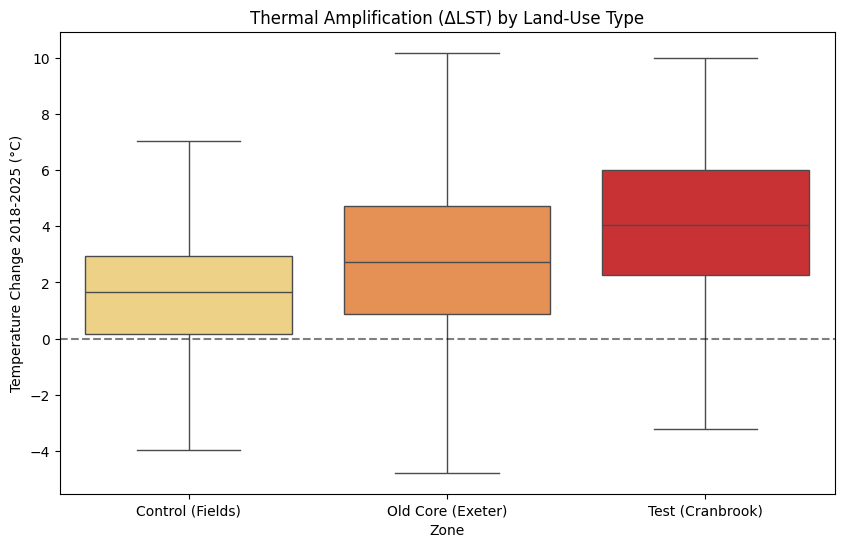

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Re-calculate the temperature change
lst_diff_native = lst_current.subtract(lst_baseline)

# Use reduceRegion to extract exact pixels
def get_thermal_stats(image, region_mask, label):
    # Get the exact name of the thermal band
    band_name = image.bandNames().get(0).getInfo()

    # Extract ALL valid data points under the mask directly into a list
    extraction = image.select([0]).updateMask(region_mask).reduceRegion(
        reducer=ee.Reducer.toList(),
        geometry=study_area_geom,
        scale=30,
        maxPixels=1e8
    ).getInfo()

    # Safely retrieve the list from the dictionary
    vals = extraction.get(band_name, [])

    print(f"✅ Extracted {len(vals)} true points for {label}")
    return pd.DataFrame({'Temp_Change': vals, 'Zone': label})

# Compile the statistical results
print("Extracting exact thermal statistics (this takes a few seconds)...")
df_thermal_stats = pd.concat([
    get_thermal_stats(lst_diff_native, zone_control_final, 'Control (Fields)'),
    get_thermal_stats(lst_diff_native, zone_old_city_final, 'Old Core (Exeter)'),
    get_thermal_stats(lst_diff_native, zone_test_final, 'Test (Cranbrook)')
])

# Generate the Chart
plt.figure(figsize=(10, 6))
sns.boxplot(x='Zone', y='Temp_Change', data=df_thermal_stats, palette="YlOrRd", showfliers=False)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Thermal Amplification (ΔLST) by Land-Use Type', fontsize=12)
plt.ylabel('Temperature Change 2018-2025 (°C)')
# Save the image to the base directory
chart1_path = os.path.join(BASE_DIR, 'Thermal_Proof.png')
plt.savefig(chart1_path, dpi=300)
plt.show()

Sampling Distance and Thermal data...
✅ Plotted 819 points for this figure


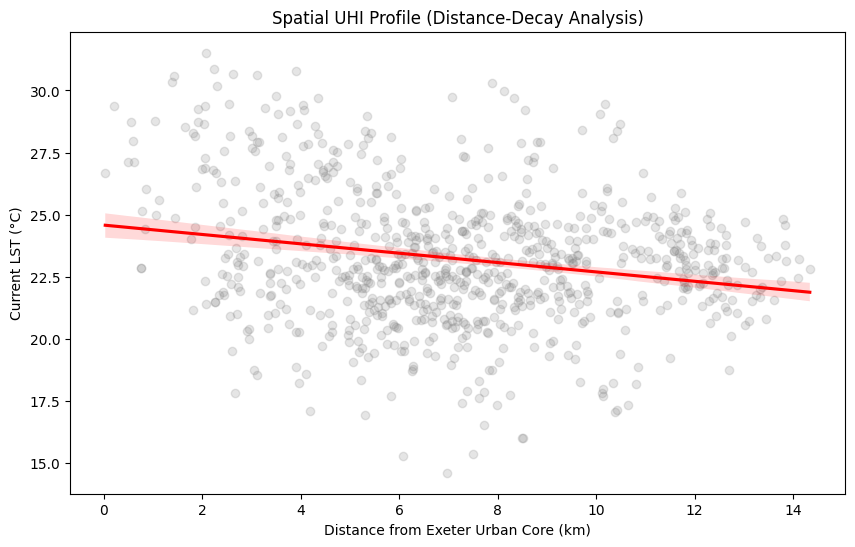

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Distance Calculation from Exeter Central Station
exeter_center = ee.Geometry.Point([-3.5275, 50.7233])

# Convert point to FeatureCollection to generate a clean distance image
dist_img = ee.FeatureCollection([ee.Feature(exeter_center)]).distance(searchRadius=50000)
dist_km = dist_img.divide(1000).rename('Distance_km')

# Extract LST vs Distance
# Use lst_current (native 30m resolution retrieve from GEE), not lst_current_10m because the 10m is just a resampled version.
print("Sampling Distance and Thermal data...")
uhi_data = lst_current.select([0]).addBands(dist_km).sample(
    region=study_area_geom,
    scale=30,
    numPixels=1000,
    geometries=False,
    dropNulls=True
).getInfo()

# Get the dynamic band name for LST
b_name = lst_current.bandNames().get(0).getInfo()

# Create a Clean DataFrame
df_uhi = pd.DataFrame({
    'Distance_km': [f['properties']['Distance_km'] for f in uhi_data['features'] if 'Distance_km' in f['properties']],
    'LST_Current': [f['properties'][b_name] for f in uhi_data['features'] if b_name in f['properties']]
})

print(f"✅ Plotted {len(df_uhi)} points for this figure")

# Plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(x='Distance_km', y='LST_Current', data=df_uhi,
            scatter_kws={'alpha':0.2, 'color':'grey'}, line_kws={'color':'red'})
plt.title('Spatial UHI Profile (Distance-Decay Analysis)', fontsize=12)
plt.xlabel('Distance from Exeter Urban Core (km)')
plt.ylabel('Current LST (°C)')
# Save the image to the base directory
chart2_path = os.path.join(BASE_DIR, 'UHI_Profile.png')
plt.savefig(chart2_path, dpi=300)
plt.show()